In [24]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

save_dir = "data/xenium-tcr-kidney/processed"

import matplotlib.pyplot as plt
import nichepca as npc
import numpy as np
import pandas as pd
import scanpy as sc
from spatialtools.clustering import leiden_unique

from spatial_tcr.tcr import get_tcr_genes

# Set the verbosity level
# sc.settings.verbosity = 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr


In [25]:
def cat_to_indicator(df, col, prefix="is_"):
    # Example of transforming categorical column to indicator columns
    series = df[col].astype(str)
    indicator_df = pd.get_dummies(series).multiply(series, axis=0)
    indicator_df = indicator_df.replace("", np.nan)
    # rename columns to is_<category>
    indicator_df.columns = [f"{prefix}{col}" for col in indicator_df.columns]
    return indicator_df

In [26]:
path = "data/xenium/processed/04.1-kidney_tcr_tsub_harmonized.h5ad"
adata = sc.read_h5ad(path)
adata.X = adata.layers["counts"].copy()
# adata.obs["sample"] = [name.split("_output-")[-1] for name in adata.obs_names]
adata

AnnData object with n_obs × n_vars = 510139 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'graph', 'log1p'
    obsm: 'cell_type_no_tcr_probs', 'spatial'
    layers: 'counts', 'log1p'

In [27]:
adata.obs["cell_type_l2"].value_counts()

cell_type_l2
PT          120985
FIB          79706
Mac          51415
TAL          46477
EC           41864
MDC          21738
PC           19094
IC           18190
VSM/P        16335
CNT          14542
DCT          14132
CD4+          9258
POD           8584
glom. EC      6554
CD8+          6509
PL            6156
B             5862
DTL           5230
PEC           4937
MC            2816
unknown       2241
NKT-like      1842
Tregs         1158
MAST          1154
MAIT           820
cycMNP         771
N              544
gdT            446
ATL            396
cDC            303
pDC             37
PapE            27
NEU             16
Name: count, dtype: int64

In [28]:
ct_col = "cell_type_l2"
ct_df = cat_to_indicator(adata.obs, "cell_type_l1", prefix="is_")
adata.obs[ct_df.columns] = ct_df

In [29]:
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()

In [30]:
adata.obs[ct_col].nunique()

33

In [31]:
radius = 20
# radius = None

knn = None
# knn = 20

adata.X = adata.layers["counts"].copy()
npc.wf.nichepca(
    adata, knn=knn, radius=radius, obs_key=ct_col, sample_key="sample", n_comps=30
)
adata.X = adata.layers["counts"].copy()

  0%|          | 0/13 [00:00<?, ?it/s]

----------- Graph Stats -----------
Number of nodes: 510139
Number of edges: 5375053
Average in-degree: 10.536447525024414
Average out-degree: 10.536447525024414
Contains self-loops: True
Is undirected: True
obs_key provided, running pipeline: agg->pca


In [32]:
leiden_unique(adata, resolution=0.5, use_rep="X_npca", n_neighbors=50)
adata.obs.leiden.nunique()

Found 299920 unique embeddings from a total of 510139


11

In [33]:
# insert original clusters for reproducibility
npca_clusters = pd.read_csv("data/xenium/npca_clusters.csv", index_col=0)
adata.obs["leiden"] = adata.obs["leiden"].astype(str)
adata.obs.loc[npca_clusters.index, "leiden"] = npca_clusters["leiden"].astype(str)
adata.obs["leiden"].value_counts()

leiden
8    167725
0     85641
5     47616
4     43857
6     37918
7     35822
1     33132
3     29776
2     19499
9      9153
Name: count, dtype: int64

In [34]:
markers = {
    "Immune": [
        "CD3E",
        "CD3D",
        "CD4",
        "CD8A",
        "CXCL13",
        "CXCR5",
        "TNF",
        "CD19",
        "MS4A1",
    ],
    "Glom.": [
        "PODXL",
        "PECAM1",
        # "PDGFRB",
    ],
    "tubuloint.": ["UMOD"],
}

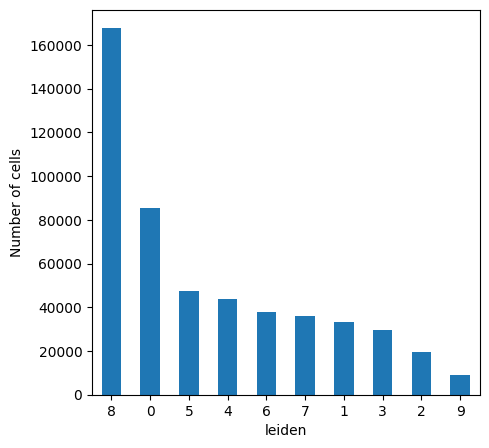

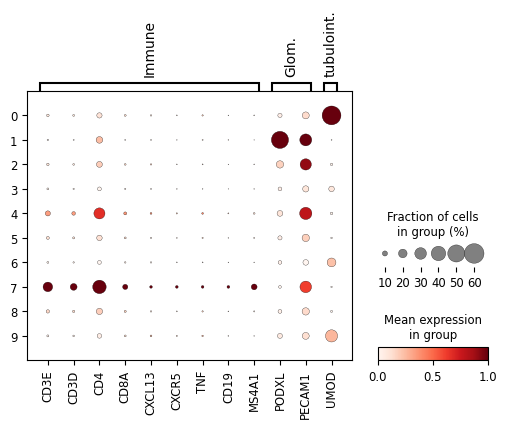

In [35]:
adata.obs["leiden"].value_counts().plot(
    kind="bar", figsize=(5, 5), ylabel="Number of cells"
)
# plt.yscale("log")
# rotate xticks
plt.xticks(rotation=0)

adata.X = adata.layers["log1p"].copy()
sc.pl.dotplot(
    adata,
    var_names=markers,
    groupby="leiden",
    standard_scale="var",
)

In [36]:
ind_df = cat_to_indicator(adata.obs, "leiden", prefix="leiden_")
adata.obs[ind_df.columns] = ind_df

In [37]:
glom_clust = 1
glom_key = f"leiden_{glom_clust}"

adata.obs[glom_key] = adata.obs[glom_key].fillna("None")

/tmp/ipykernel_105432/4182441765.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


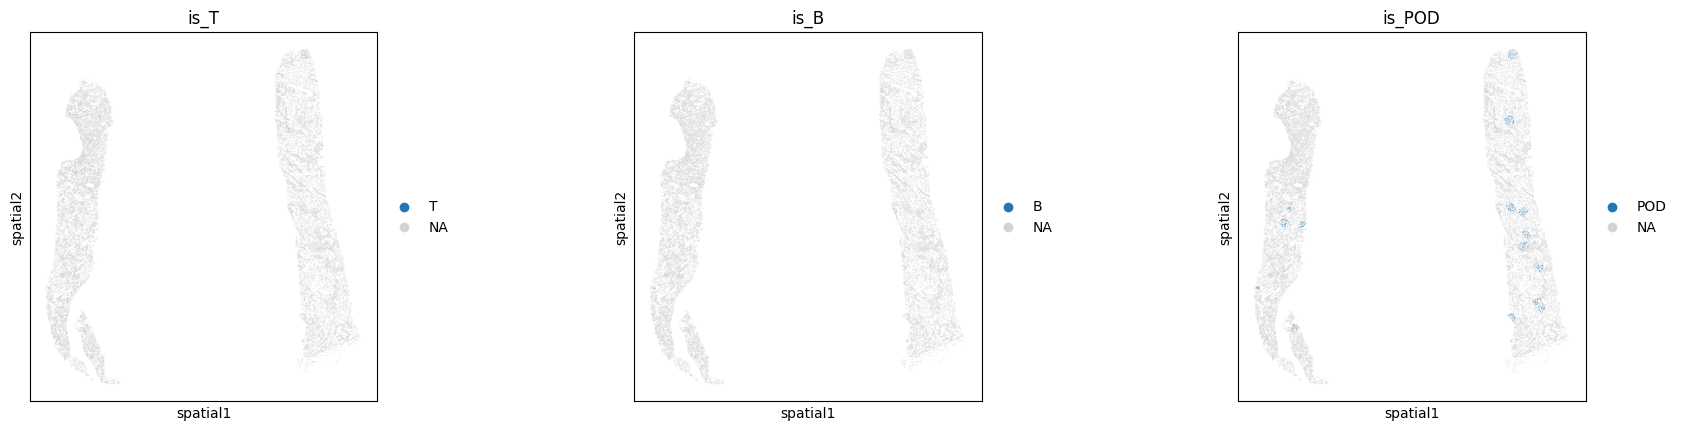

/tmp/ipykernel_105432/4182441765.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color=glom_key, na_color="lightgray", spot_size=10)


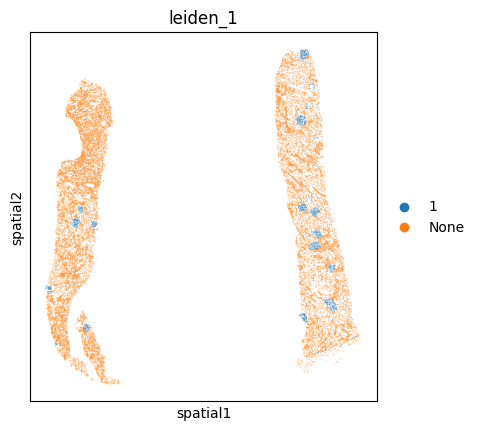

In [38]:
for s in adata.obs["sample"].unique():
    ad_sub = adata[adata.obs["sample"] == s].copy()
    sc.pl.spatial(
        ad_sub, color=["is_T", "is_B", "is_POD"], na_color="lightgray", spot_size=10
    )
    sc.pl.spatial(ad_sub, color=glom_key, na_color="lightgray", spot_size=10)
    break

/tmp/ipykernel_105432/2148143807.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


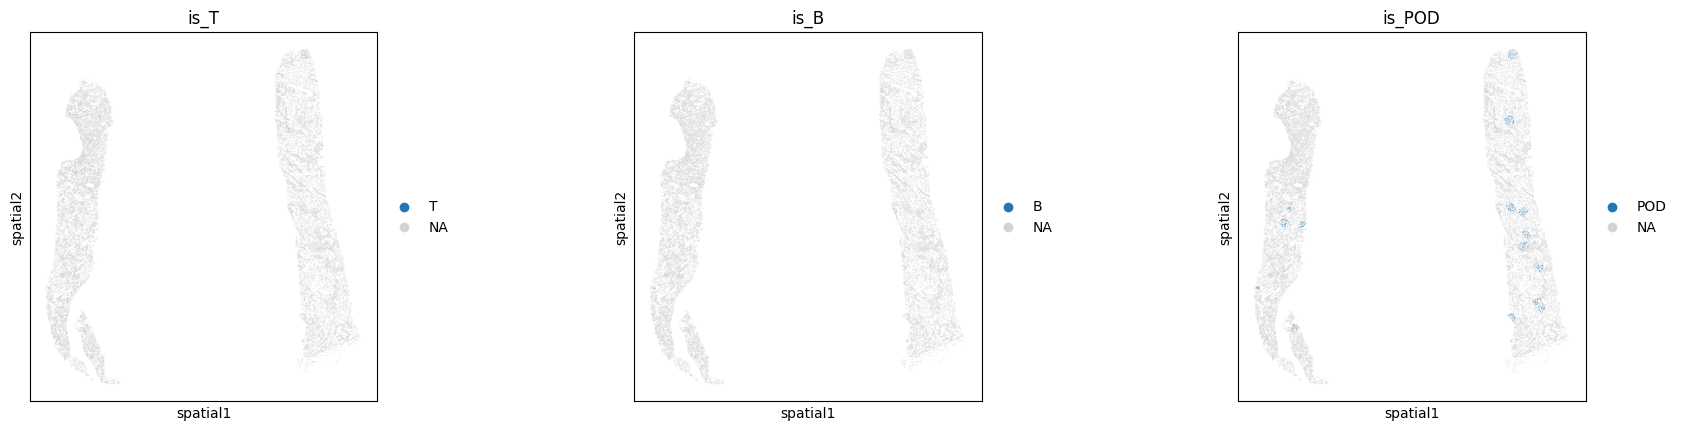

/tmp/ipykernel_105432/2148143807.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color=not_na_cols, na_color="lightgray", spot_size=10)


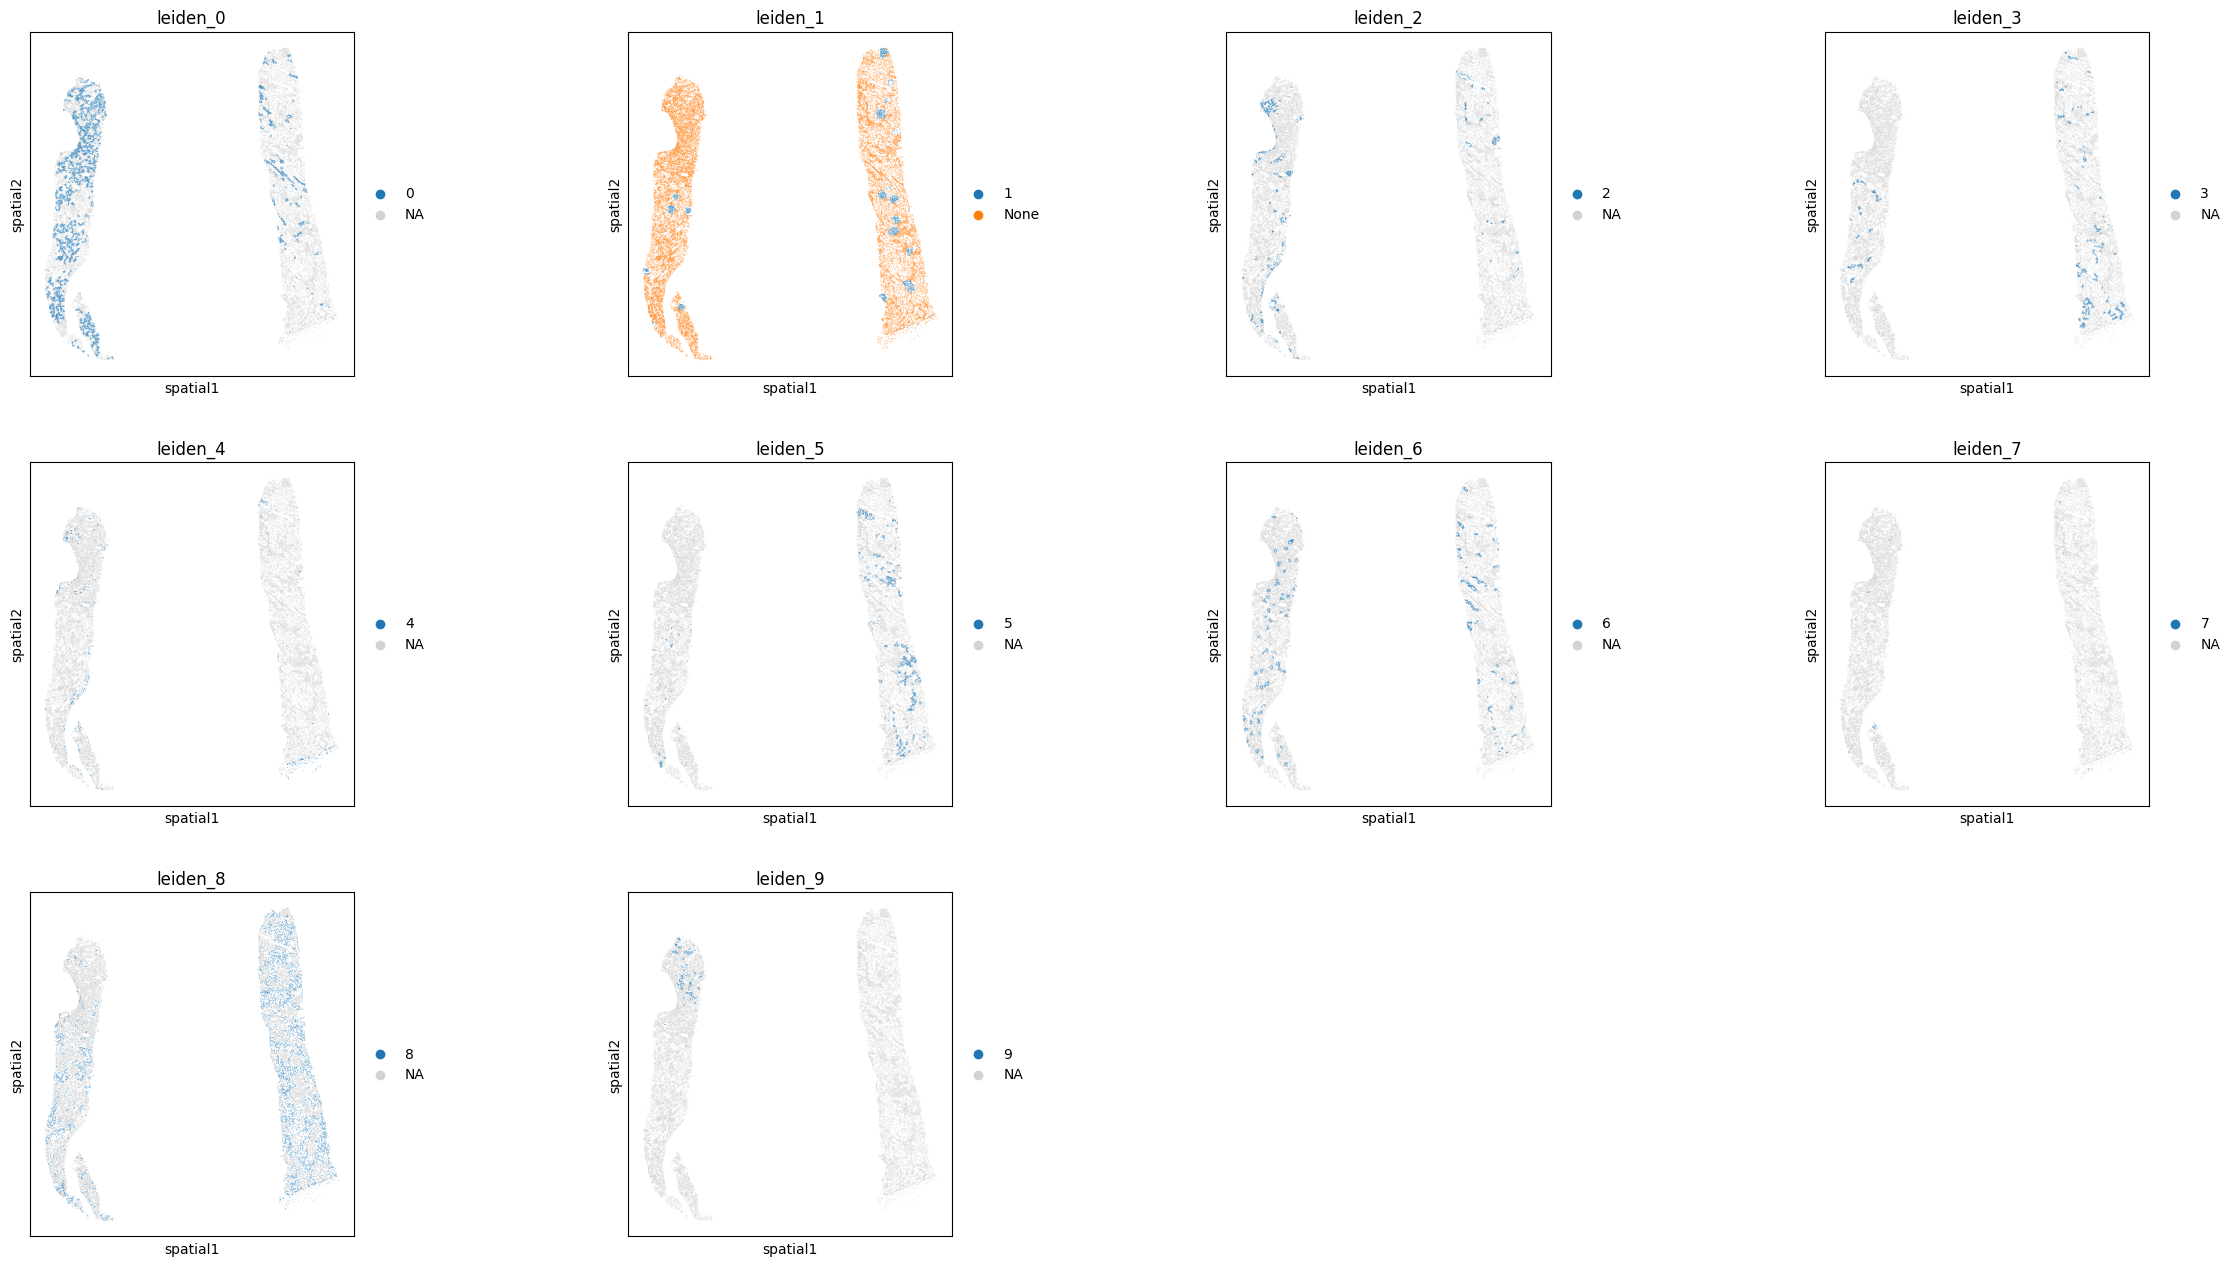

In [39]:
# plt.rcParams["figure.figsize"] = (15, 15)
# plt.rcParams["figure.dpi"] = 300

for s in adata.obs["sample"].unique():
    ad_sub = adata[adata.obs["sample"] == s].copy()
    sc.pl.spatial(
        ad_sub, color=["is_T", "is_B", "is_POD"], na_color="lightgray", spot_size=10
    )

    not_na_cols = [c for c in ind_df.columns if ad_sub.obs[c].notna().any()]
    sc.pl.spatial(ad_sub, color=not_na_cols, na_color="lightgray", spot_size=10)
    break

## clean and split gloms

In [40]:
from spatialtools.spatial import annotate_ccs, filter_ccs

ad_glom = adata[adata.obs["leiden"] == str(glom_clust)].copy()

# calc graph
npc.gc.construct_multi_sample_graph(ad_glom, radius=20, sample_key="sample")

annotate_ccs(ad_glom)

ad_glom = filter_ccs(ad_glom, min_cells=25)

  0%|          | 0/13 [00:00<?, ?it/s]

----------- Graph Stats -----------
Number of nodes: 33132
Number of edges: 307212
Average in-degree: 9.272364616394043
Average out-degree: 9.272364616394043
Contains self-loops: True
Is undirected: True


/tmp/ipykernel_105432/2810073357.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="cc", spot_size=10)


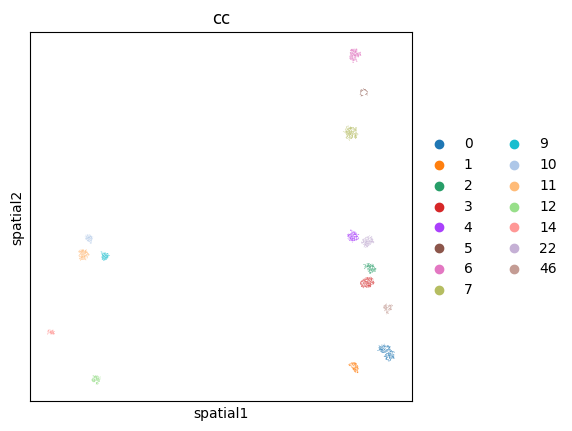

cc
0     217
7     203
6     188
3     170
22    159
4     154
11    151
2     116
1     115
12    101
9      88
46     86
10     74
14     60
5      35
Name: count, dtype: int64

In [41]:
for s in ad_glom.obs["sample"].unique():
    print()
    ad_sub = ad_glom[ad_glom.obs["sample"] == s].copy()
    sc.pl.spatial(ad_sub, color="cc", spot_size=10)
    break
ad_sub.obs["cc"].value_counts()

In [42]:
adata.obs["glom_annot"] = None
adata.obs.loc[ad_glom.obs_names, "glom_annot"] = "glom_" + ad_glom.obs["cc"].astype(str)
adata.obs["in_glom"] = adata.obs["glom_annot"].notna()

/tmp/ipykernel_105432/3275121085.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


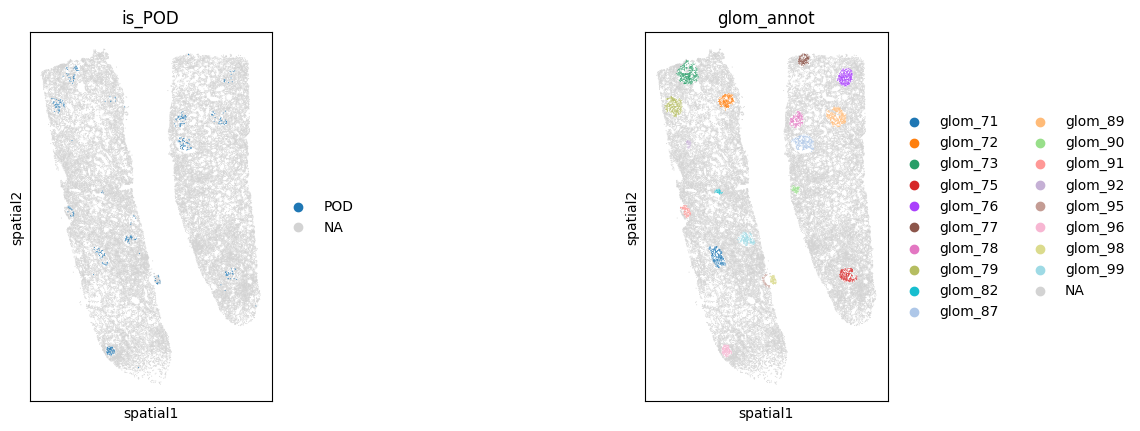

In [43]:
for s in adata.obs["sample"].unique()[1::]:
    ad_sub = adata[adata.obs["sample"] == s].copy()
    sc.pl.spatial(
        ad_sub, color=["is_POD", "glom_annot"], na_color="lightgray", spot_size=10
    )
    break

In [44]:
# # remove leiden cols
columns_to_drop = [c for c in adata.obs.columns if c.startswith("leiden_")]

print(columns_to_drop)

adata.obs.drop(columns=columns_to_drop, inplace=True)

['leiden_0', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9']


In [45]:
adata

AnnData object with n_obs × n_vars = 510139 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_c

In [46]:
adata.write_h5ad("data/xenium/processed/05.1-kidney_tcr_nichepca.h5ad")

/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
